In [110]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

In [111]:
FILE_PATH = "C:\\Users\\ramme\\OneDrive\\Desktop\\Demand-Forecasting\\notebooks\\Braxton_data_May07_2024_dec16_2025_complete.csv"
TEST_PERIOD = 5
FORECAST_PERIOD = 6
SEASONAL_PERIOD = 7

In [112]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100

def mase(y_true, y_pred, y_train):
    naive_error = np.mean(np.abs(y_train[1:] - y_train[:-1]))
    model_error = np.mean(np.abs(y_true - y_pred))
    return model_error / naive_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [113]:
df = pd.read_csv(FILE_PATH)

df.rename(columns={
    "Date": "Day",
    "unit_sold": "unit_sold"
}, inplace=True)

# Explicit column usage
df["Day"] = pd.to_datetime(df["Day"])
df["unit_sold"] = pd.to_numeric(df["unit_sold"], errors="coerce")

In [114]:
df.head()

,Day,sku_id,unit_sold
0,2024-05-07,BXCL1756,1
1,2024-05-07,BXCM1608,1
2,2024-05-07,BXCM1653,1
3,2024-05-07,BXCM3797,1
4,2024-05-07,BXCM4772,1


In [115]:
### Select a particular SKU

df = df[df["sku_id"]=="BXCM5157"]
df

,Day,sku_id,unit_sold
134,2024-05-07,BXCM5157,0
631,2024-05-08,BXCM5157,0
1128,2024-05-09,BXCM5157,0
1625,2024-05-10,BXCM5157,0
2122,2024-05-11,BXCM5157,0
...,...,...,...
290382,2025-12-12,BXCM5157,2
290879,2025-12-13,BXCM5157,0
291376,2025-12-14,BXCM5157,1
291873,2025-12-15,BXCM5157,0


In [116]:
monthly_df = (
        df
        .groupby(
            ["sku_id", pd.Grouper(key="Day", freq="MS")],  # MS = month start
            as_index=False
        )
        .agg(unit_sold=("unit_sold", "sum"))
)

monthly_df.head()

,sku_id,Day,unit_sold
0,BXCM5157,2024-05-01,0
1,BXCM5157,2024-06-01,1
2,BXCM5157,2024-07-01,18
3,BXCM5157,2024-08-01,19
4,BXCM5157,2024-09-01,17


In [117]:
# monthly["unit_price"] = monthly["Sales"] / monthly["unit_sold"]
# monthly["unit_price"] = monthly["unit_price"].replace([np.inf, -np.inf], np.nan)
# monthly["unit_price"].fillna(method="ffill", inplace=True)

# Holiday feature (US Federal)
# from pandas.tseries.holiday import USFederalHolidayCalendar
# cal = USFederalHolidayCalendar()
# holidays = cal.holidays(start=monthly_df["Day"].min(), end=monthly_df["Day"].max())

# # monthly_df["holiday"] = monthly_df["Day"].isin(holidays).astype(int)

# Drop Sales (not needed anymore)
# monthly.drop(columns=["Sales"], inplace=True)

# monthly.head()

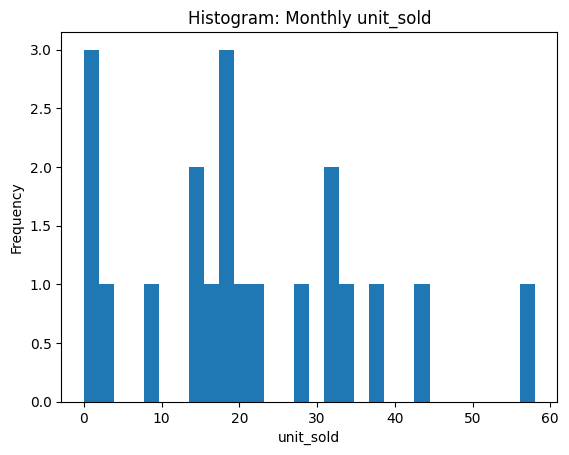

In [118]:
plt.figure()
plt.hist(monthly_df["unit_sold"], bins=30)
plt.title("Histogram: Monthly unit_sold")
plt.xlabel("unit_sold")
plt.ylabel("Frequency")
plt.show()

In [119]:
# corr = monthly[["unit_sold", "Promotions", "holiday", "unit_price"]].corr()

# plt.figure()
# im = plt.imshow(corr, aspect="auto")

# plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
# plt.yticks(range(len(corr)), corr.columns)
# plt.colorbar(im)

# # Add correlation values inside the grid
# for i in range(len(corr)):
#     for j in range(len(corr)):
#         plt.text(
#             j, i,
#             f"{corr.iloc[i, j]:.2f}",
#             ha="center",
#             va="center",
#             color="black"
#         )

# plt.title("Correlation Heatmap")
# plt.tight_layout()
# plt.show()


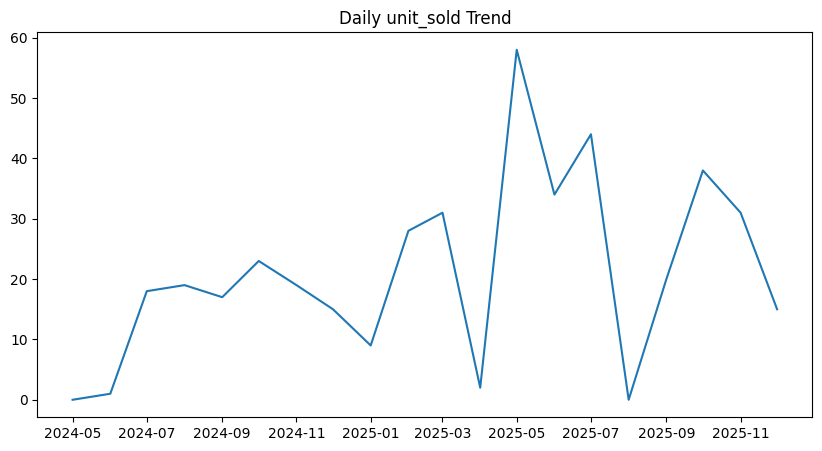

In [120]:
# Trend
# plt.figure()
plt.figure(figsize=(10, 5))
plt.plot(monthly_df["Day"], monthly_df["unit_sold"])
plt.title("Daily unit_sold Trend")
plt.show()

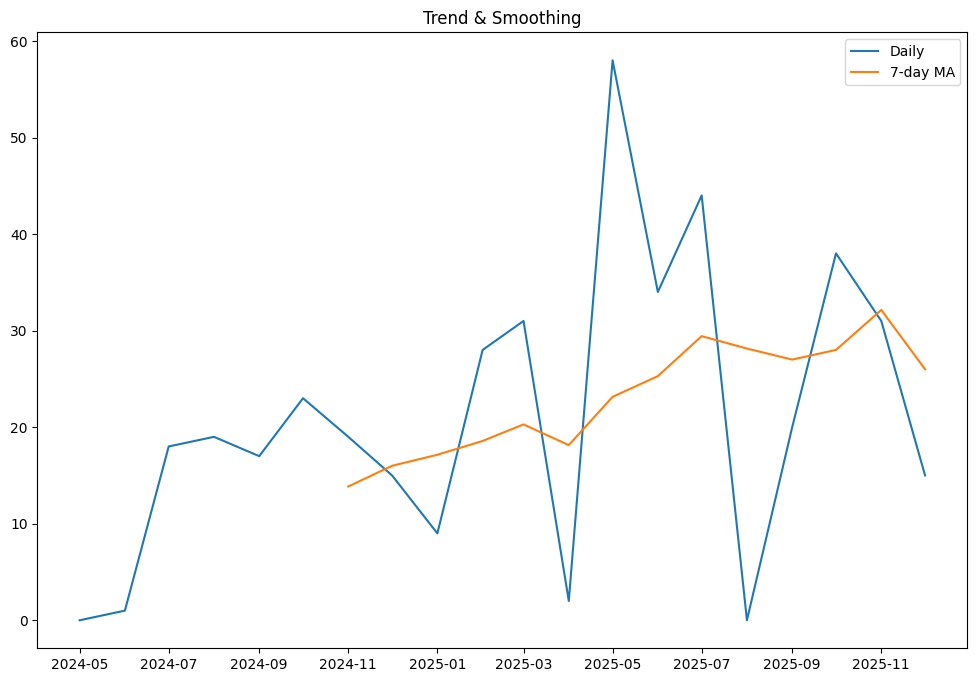

In [121]:
# Rolling mean
plt.figure(figsize=(12,8))
plt.plot(monthly_df["Day"], monthly_df["unit_sold"], label="Daily")
plt.plot(monthly_df["Day"], monthly_df["unit_sold"].rolling(7).mean(), label="7-day MA")
plt.legend()
plt.title("Trend & Smoothing")
plt.show()

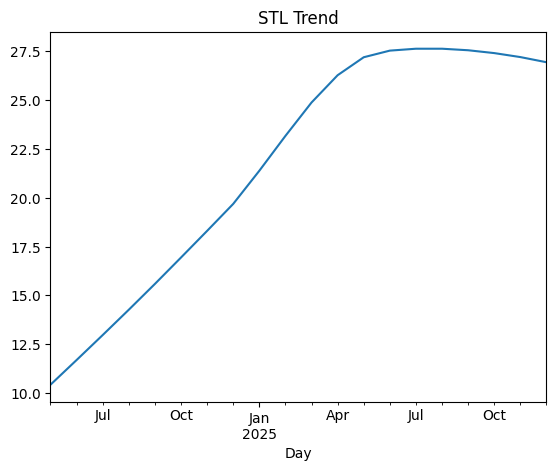

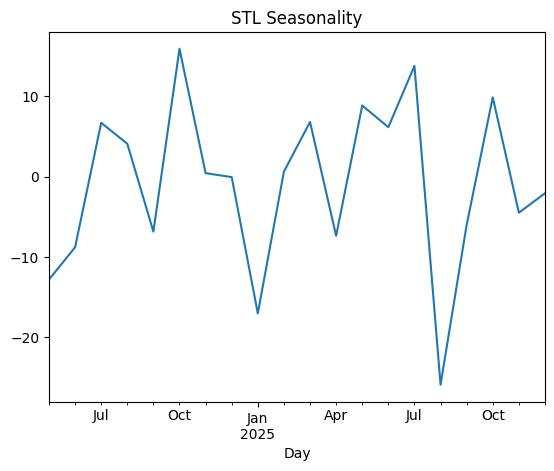

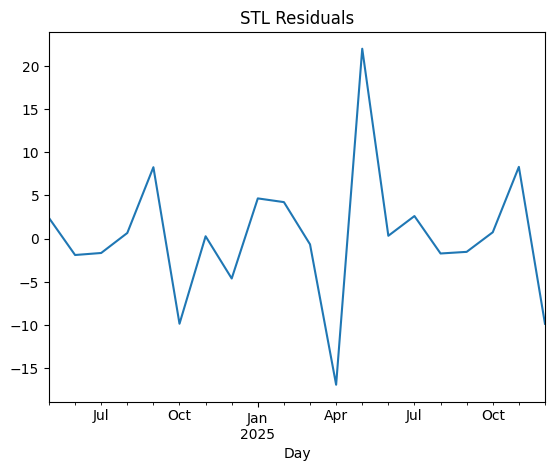

In [122]:
# STL decomposition
stl = STL(monthly_df.set_index("Day")["unit_sold"], period=SEASONAL_PERIOD)
res = stl.fit()

res.trend.plot(title="STL Trend")
plt.show()

res.seasonal.plot(title="STL Seasonality")
plt.show()

res.resid.plot(title="STL Residuals")
plt.show()

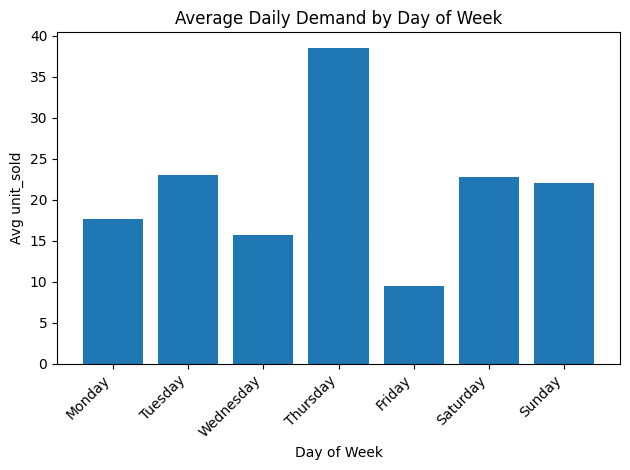

Highest average demand: Thursday (38.50)


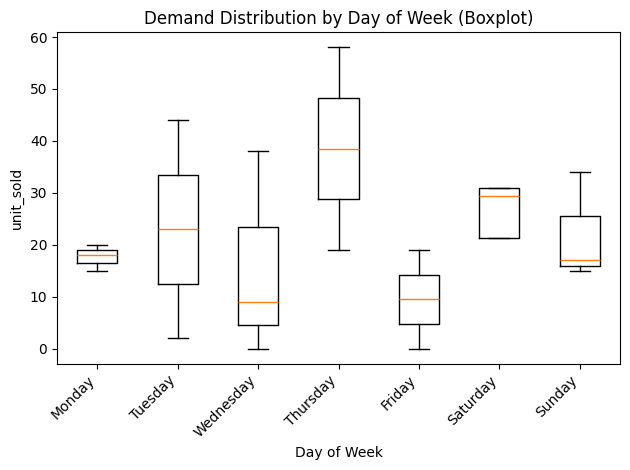

In [123]:
import pandas as pd
import matplotlib.pyplot as plt

# Assumes you already have `monthly` with:
# monthly["Day"] as datetime and monthly["unit_sold"] as numeric

tmp = monthly_df.copy()
tmp["dow_name"] = tmp["Day"].dt.day_name()
tmp["dow"] = tmp["Day"].dt.dayofweek  # Monday=0 ... Sunday=6

# Order Monday → Sunday
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# 1) Average demand by day of week
dow_mean = (tmp.groupby("dow_name")["unit_sold"]
              .mean()
              .reindex(order))

plt.figure()
plt.bar(dow_mean.index, dow_mean.values)
plt.title("Average Daily Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Avg unit_sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print best day
best_day = dow_mean.idxmax()
print(f"Highest average demand: {best_day} ({dow_mean.max():.2f})")

# 2) Median demand by day of week (more robust to spikes/outliers)
# dow_median = (tmp.groupby("dow_name")["unit_sold"]
#                 .median()
#                 .reindex(order))

# plt.figure()
# plt.bar(dow_median.index, dow_median.values)
# plt.title("Median Daily Demand by Day of Week")
# plt.xlabel("Day of Week")
# plt.ylabel("Median unit_sold")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()

# best_day_med = dow_median.idxmax()
# print(f"Highest median demand: {best_day_med} ({dow_median.max():.2f})")

# 3) Distribution view: boxplot by day of week (recommended)
data = [tmp.loc[tmp["dow_name"] == d, "unit_sold"].dropna().values for d in order]

plt.figure()
plt.boxplot(data, labels=order, showfliers=False)
plt.title("Demand Distribution by Day of Week (Boxplot)")
plt.xlabel("Day of Week")
plt.ylabel("unit_sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# # 4) Optional: Day-of-week share of weekly total (useful if levels change over time)
# dow_sum = (tmp.groupby("dow_name")["unit_sold"]
#              .sum()
#              .reindex(order))
# dow_share = dow_sum / dow_sum.sum()

# plt.figure()
# plt.bar(dow_share.index, dow_share.values)
# plt.title("Share of Total Demand by Day of Week")
# plt.xlabel("Day of Week")
# plt.ylabel("Share")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()

# print("\nDay-of-week summary:")
# summary = pd.DataFrame({
#     "mean": dow_mean,
#     "median": dow_median,
#     "total": dow_sum,
#     "share": dow_share
# }).sort_values("mean", ascending=False)

# print(summary)


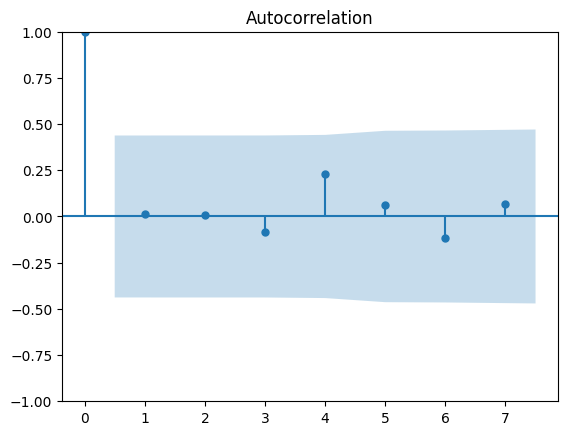

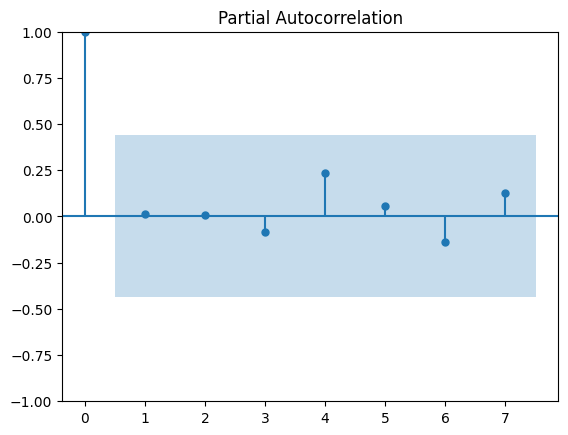

In [124]:
# ACF & PACF
plot_acf(monthly_df["unit_sold"], lags=7)
plt.show()

plot_pacf(monthly_df["unit_sold"], lags=7)
plt.show()

In [125]:
train = monthly_df.iloc[:-TEST_PERIOD]
test = monthly_df.iloc[-TEST_PERIOD:]

print(len(train), len(test))

15 5


In [126]:
prophet_train = train.rename(
    columns={"Day": "ds", "unit_sold": "y"}
)

model_prophet = Prophet(
    # montly_seasonality=True,
    yearly_seasonality=True
)

# model_prophet.add_regressor("Promotions")
# model_prophet.add_regressor("holiday")
# model_prophet.add_regressor("unit_price")

model_prophet.fit(prophet_train)

18:17:24 - cmdstanpy - INFO - Chain [1] start processing
18:17:25 - cmdstanpy - INFO - Chain [1] done processing


In [127]:
prophet_test = test.rename(columns={"Day": "ds", "unit_sold": "y"})
prophet_pred = model_prophet.predict(prophet_test)

prophet_pred

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-08-01,50.782738,61.136355,62.947165,49.887852,51.698662,11.248503,11.248503,11.248503,11.248503,11.248503,11.248503,0.0,0.0,0.0,62.031242
1,2025-09-01,55.526780,75.535533,81.727111,52.549695,58.741273,22.985838,22.985838,22.985838,22.985838,22.985838,22.985838,0.0,0.0,0.0,78.512617
2,2025-10-01,60.117788,75.905369,88.129899,54.297527,66.522058,21.607842,21.607842,21.607842,21.607842,21.607842,21.607842,0.0,0.0,0.0,81.725630
3,2025-11-01,64.861830,44.953398,64.075312,55.493854,74.615768,-10.540456,-10.540456,-10.540456,-10.540456,-10.540456,-10.540456,0.0,0.0,0.0,54.321374
4,2025-12-01,69.452838,61.222630,88.361060,56.604153,83.742583,4.618478,4.618478,4.618478,4.618478,4.618478,4.618478,0.0,0.0,0.0,74.071316


In [128]:
prophet_mae = mean_absolute_error(prophet_test["y"], prophet_pred["yhat"])
# prophet_mape = mape(prophet_test["y"], prophet_pred["yhat"])
prophet_rmse = rmse(prophet_test["y"], prophet_pred["yhat"])

print(f"Prophet  → MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}")

Prophet  → MAE: 49.33, RMSE: 51.41


In [129]:
y_train = train["unit_sold"].astype(float).values
y_test  = test["unit_sold"].astype(float).values

In [130]:
# exog_cols = ["Promotions", "holiday", "unit_price"]
arima_order = (1, 1, 1)

arima = ARIMA(
    train["unit_sold"],
    order=arima_order,
)

arima_fit = arima.fit()

arima_test_pred = arima_fit.forecast(
    steps=TEST_PERIOD,
)

In [131]:
arima_mae = mean_absolute_error(y_test, arima_test_pred)
# arima_mape = mape(y_test, arima_test_pred)
arima_rmse = rmse(y_test, arima_test_pred)

print(f"\nARIMA{arima_order} → MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}")


ARIMA(1, 1, 1) → MAE: 18.69, RMSE: 22.61


In [132]:
sarima_order = (1, 1, 1)
seasonal_order = (1, 1, 1, 7)

sarima_model = SARIMAX(
    y_train,
    order=sarima_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

# Forecast for test window
sarima_test_pred = sarima_fit.forecast(steps=TEST_PERIOD)

In [133]:
sarima_mae = mean_absolute_error(y_test, sarima_test_pred)
# sarima_mape = mape(y_test, sarima_test_pred)
sarima_rmse = rmse(y_test, sarima_test_pred)

print("\nSARIMA MODEL PERFORMANCE (5-day test)")
print("------------------------------------")
print(f"SARIMA{sarima_order}{seasonal_order} → "
      f"MAE: {sarima_mae:.2f},"
      f"RMSE: {sarima_rmse:.2f}")


SARIMA MODEL PERFORMANCE (5-day test)
------------------------------------
SARIMA(1, 1, 1)(1, 1, 1, 7) → MAE: 28.36,RMSE: 34.66


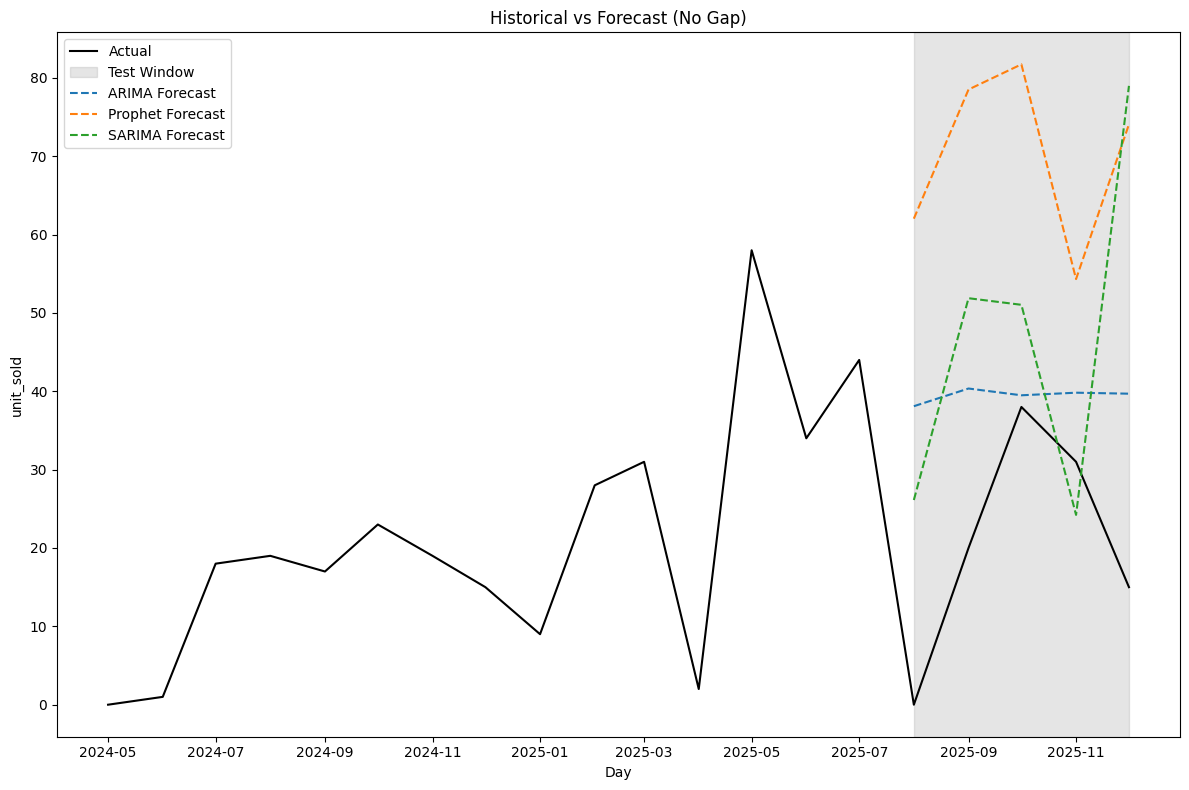

In [134]:
plt.figure(figsize=(12,8))

# Plot full actual series (continuous)
plt.plot(monthly_df["Day"], monthly_df["unit_sold"], label="Actual", color="black")

# Highlight test period
plt.axvspan(
    test["Day"].min(),
    test["Day"].max(),
    color="gray",
    alpha=0.2,
    label="Test Window"
)

# Plot forecasts
plt.plot(test["Day"], arima_test_pred, label="ARIMA Forecast", linestyle="--")
plt.plot(test["Day"], prophet_pred["yhat"], label="Prophet Forecast", linestyle="--")
plt.plot(test["Day"], sarima_test_pred, label="SARIMA Forecast", linestyle="--")


plt.title("Historical vs Forecast (No Gap)")
plt.xlabel("Day")
plt.ylabel("unit_sold")
plt.legend()
plt.tight_layout()
plt.show()


In [135]:
# ------------------------------------------------------------
# 6 Month FORECAST
# ------------------------------------------------------------

future_dates = pd.date_range(
    start=monthly_df["Day"].max() + pd.Timedelta(days=1),
    periods=FORECAST_PERIOD,
    freq="M"
)

future_prophet = pd.DataFrame({
    "ds": future_dates,
    # "Promotions": 0,
    # "holiday": future_dates.isin(holidays).astype(int),
    # "unit_price": monthly["unit_price"].iloc[-1]
})

prophet_6 = model_prophet.predict(future_prophet)

arima_6 = arima_fit.forecast(steps=FORECAST_PERIOD)

sarima_6 = sarima_fit.forecast(steps=FORECAST_PERIOD)

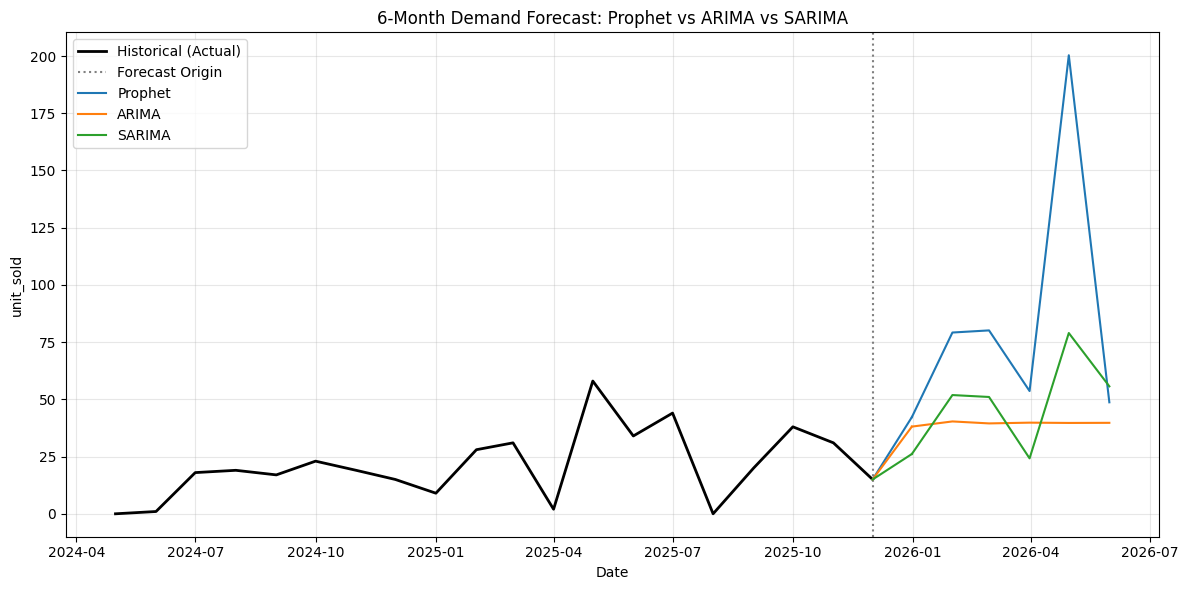

In [136]:
plt.figure(figsize=(12, 6))

# ------------------------------------------------------------
# HISTORICAL DATA
# ------------------------------------------------------------
plt.plot(
    monthly_df["Day"],
    monthly_df["unit_sold"],
    color="black",
    linewidth=2,
    label="Historical (Actual)"
)

# ------------------------------------------------------------
# FORECAST ORIGIN
# ------------------------------------------------------------
forecast_origin_date = monthly_df["Day"].iloc[-1]
forecast_origin_value = monthly_df["unit_sold"].iloc[-1]

plt.axvline(
    forecast_origin_date,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Forecast Origin"
)


plt.plot(
    [forecast_origin_date, future_dates[0]],
    [forecast_origin_value, prophet_6["yhat"].iloc[0]],
    color="tab:blue"
)

plt.plot(
    [forecast_origin_date, future_dates[0]],
    [forecast_origin_value, arima_6.iloc[0]],
    color="tab:orange"
)

plt.plot(
    [forecast_origin_date, future_dates[0]],
    [forecast_origin_value, sarima_6[0]],
    color="tab:green"
)

# ------------------------------------------------------------
# FORECAST LINES
# ------------------------------------------------------------
plt.plot(
    future_dates,
    prophet_6["yhat"],
    linestyle="-",
    color="tab:blue",
    label="Prophet"
)

plt.plot(
    future_dates,
    arima_6,
    linestyle="-",
    color="tab:orange",
    label="ARIMA"
)

plt.plot(
    future_dates,
    sarima_6,
    linestyle="-",
    color="tab:green",
    label="SARIMA"
)

# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------
plt.title("6-Month Demand Forecast: Prophet vs ARIMA vs SARIMA")
plt.xlabel("Date")
plt.ylabel("unit_sold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [137]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["Prophet", "ARIMA", "SARIMA"],
    "MAE": [
        prophet_mae,
        arima_mae,
        sarima_mae
    ],
    "RMSE": [
        prophet_rmse,
        arima_rmse,
        sarima_rmse
    ]
})

# Optional: round values for readability
metrics_df[["MAE", "RMSE"]] = metrics_df[["MAE", "RMSE"]].round(3)
metrics_df


,Model,MAE,RMSE
0,Prophet,49.332,51.414
1,ARIMA,18.691,22.607
2,SARIMA,28.359,34.664
